In [1]:
from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

/Users/amyguan/miniforge3/envs/weaver/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [21]:
augmented = {'MATH500': 0.840, 'GPQA': 0.359, 'MMLU': 0.901}

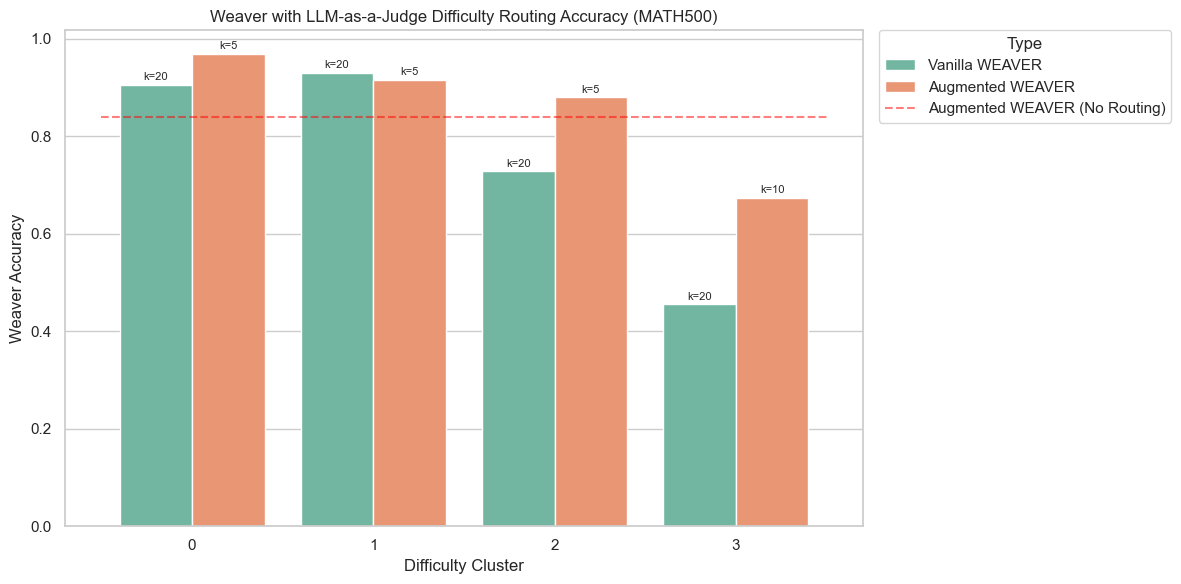

In [34]:
def plot(dataset):
    """Plot accuracy by difficulty bucket for a given dataset CSV in analysis/."""
    df = pd.read_csv(f"{dataset.lower()}_clusters.csv")

    order = sorted(df["Difficulty"].unique())
    hue_order = df["Type"].unique()
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x="Difficulty", y="Accuracy", data=df, hue="Type", order=order, hue_order=hue_order, palette="Set2")
    ax.set_xlabel("Difficulty Cluster")
    ax.set_ylabel("Weaver Accuracy")
    ax.set_title(f"Weaver with LLM-as-a-Judge Difficulty Routing Accuracy ({dataset})")

    grouped = {t: subdf.set_index("Difficulty").loc[order] for t, subdf in df.groupby("Type")}
    for bars, hue in zip(ax.containers, hue_order):
        subdf = grouped[hue]
        labels = [f"k={int(subdf.loc[d, 'Num Verifiers'])}" for d in order]
        ax.bar_label(bars, labels=labels, padding=2, fontsize=8)

    xmin, xmax = ax.get_xlim()
    ax.hlines(augmented[dataset], xmin=xmin, xmax=xmax, color="red", linestyle="--", label="Augmented WEAVER (No Routing)", alpha=0.5)

    ax.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig(f"llm_weaver_acc_{dataset}.png")
    plt.show()

plot("MATH500")

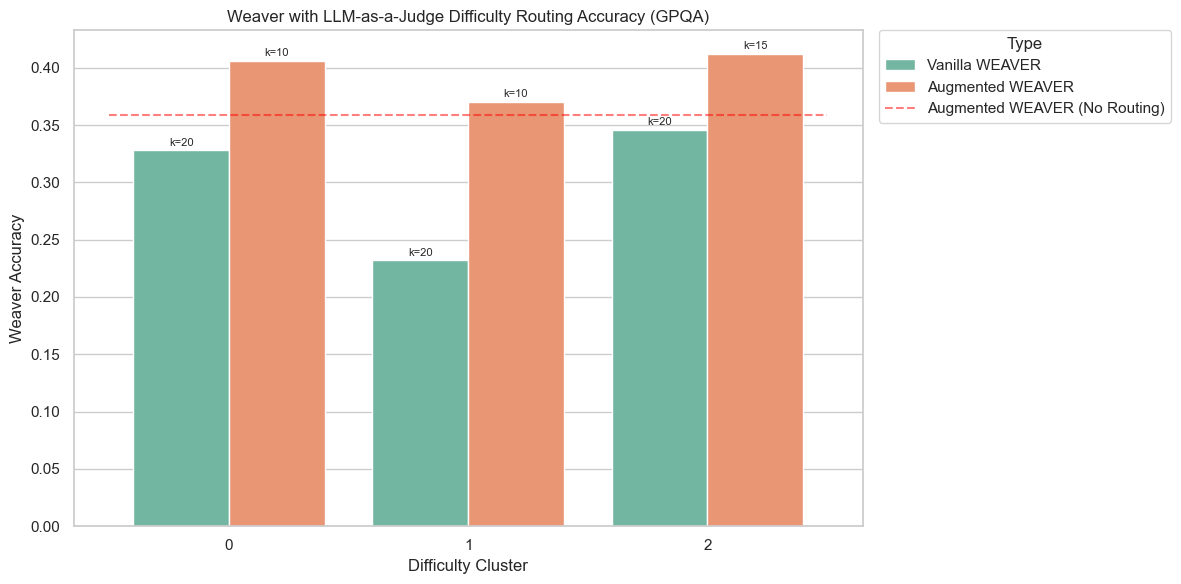

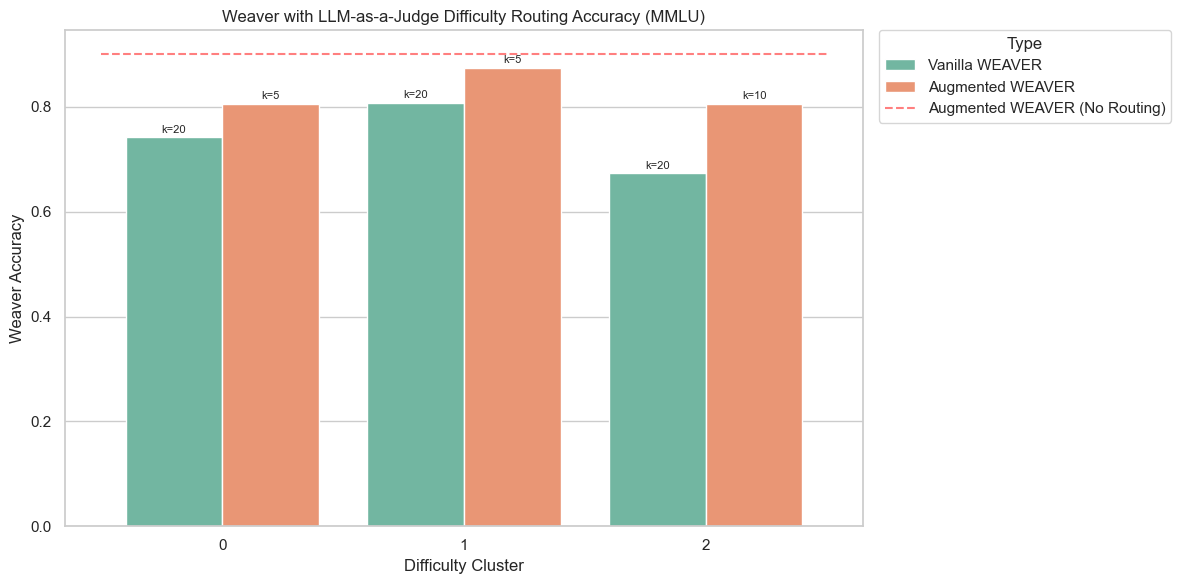

In [35]:
plot("GPQA")
plot("MMLU")